# FM-LLM - Reproduction Pipeline

In [1]:
import torch
import transformers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

print(f"PyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\Y\Documents\03_AIT\DISAL\fm_llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version: 2.13.0+cpu
Transformers Version: 5.14.1
Using device: cpu


In [2]:
# Download official ETTh1 dataset spreadsheet
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
raw_dataframe = pd.read_csv(url)

numeric_data = raw_dataframe.drop(columns=['date'])
real_dataset_tensor = torch.tensor(numeric_data.values, dtype=torch.float32)

print(f"Columns: {list(numeric_data.columns)}")
print(f"Real Dataset Dimensions: {real_dataset_tensor.shape} (Hours, Sensors)")

Columns: ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']
Real Dataset Dimensions: torch.Size([17420, 7]) (Hours, Sensors)


## 1. Chronological Train / Val / Test Split

In [3]:
# Standard ETTh1 split convention (12 / 4 / 4 months), matches every baseline in the paper
HOURS_PER_MONTH = 30 * 24
num_train = 12 * HOURS_PER_MONTH
num_val = 4 * HOURS_PER_MONTH
num_test = 4 * HOURS_PER_MONTH

seq_len = 672   # look-back window (paper's T)
pred_len = 96   # forecast horizon (paper's P, horizon=96 case)

train_end = num_train
val_end = num_train + num_val
test_end = num_train + num_val + num_test

# val/test borrow seq_len hours of history from the previous split so their first
# window still has a full look-back; the predicted target never crosses the boundary
train_data = numeric_data.iloc[0:train_end]
val_data = numeric_data.iloc[train_end - seq_len : val_end]
test_data = numeric_data.iloc[val_end - seq_len : test_end]

print(f"Train: {len(train_data)} hours")
print(f"Val:   {len(val_data)} hours")
print(f"Test:  {len(test_data)} hours")

Train: 8640 hours
Val:   3552 hours
Test:  3552 hours


## 2. Per-Channel Normalization (stats from train split only)

In [4]:
channel_mean = train_data.mean(axis=0)
channel_std = train_data.std(axis=0)

def normalize(df):
    return (df - channel_mean) / channel_std

train_norm = normalize(train_data).values.astype("float32")
val_norm = normalize(val_data).values.astype("float32")
test_norm = normalize(test_data).values.astype("float32")

print(f"train_norm mean/std: {train_norm.mean():.4f} / {train_norm.std():.4f}")
print(f"test_norm  mean/std: {test_norm.mean():.4f} / {test_norm.std():.4f}")

train_norm mean/std: 0.0000 / 0.9999
test_norm  mean/std: -0.0442 / 1.0495


## 3. Patch Tokenization

In [5]:
def create_time_tokens(raw_data, patch_len=96):

    seq_len, num_features = raw_data.shape

    x = raw_data.permute(1, 0)

    tokens = x.unfold(dimension=-1, size=patch_len, step=patch_len)

    return tokens


## 4. Sliding-Window Dataset

In [6]:
class ForecastWindowDataset(torch.utils.data.Dataset):
    """Sliding window: history (seq_len) -> future (pred_len), one hour at a time."""

    def __init__(self, data, seq_len=672, pred_len=96):
        self.data = torch.from_numpy(data)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        history = self.data[idx : idx + self.seq_len]
        future = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return history, future


train_dataset = ForecastWindowDataset(train_norm, seq_len, pred_len)
val_dataset = ForecastWindowDataset(val_norm, seq_len, pred_len)
test_dataset = ForecastWindowDataset(test_norm, seq_len, pred_len)

print(f"Training examples:   {len(train_dataset)}")
print(f"Validation examples: {len(val_dataset)}")
print(f"Test examples:       {len(test_dataset)}")

Training examples:   7873
Validation examples: 2785
Test examples:       2785


## 5. Batching

In [7]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

history_batch, future_batch = next(iter(train_loader))
print(f"Batch history shape: {tuple(history_batch.shape)}  (batch, hours, sensors)")
print(f"Batch future shape:  {tuple(future_batch.shape)}  (batch, hours, sensors)")

# Same chunking as create_time_tokens above, applied to a whole batch at once
batch_tokens = history_batch.permute(0, 2, 1).unfold(-1, pred_len, pred_len)
print(f"Batch tokenized shape: {tuple(batch_tokens.shape)}  (batch, sensors, chunks, chunk_length)")

Batch history shape: (32, 672, 7)  (batch, hours, sensors)
Batch future shape:  (32, 96, 7)  (batch, hours, sensors)
Batch tokenized shape: (32, 7, 7, 96)  (batch, sensors, chunks, chunk_length)


## 6. Sample Visualization

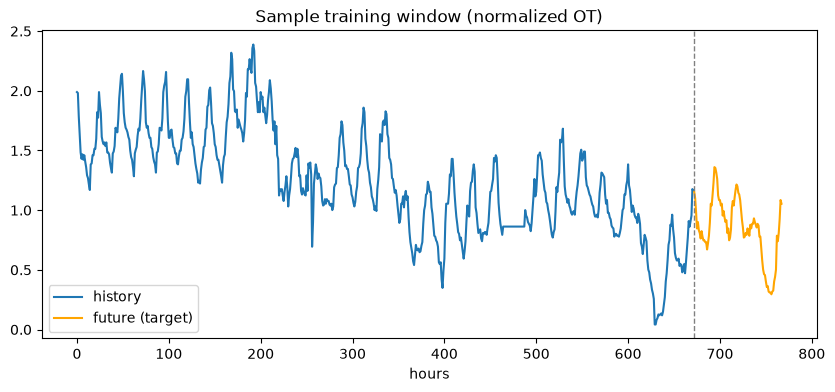

In [8]:
history_example, future_example = train_dataset[1000]
channel_idx = 6  # OT

plt.figure(figsize=(10, 4))
plt.plot(range(seq_len), history_example[:, channel_idx], label="history")
plt.plot(range(seq_len, seq_len + pred_len), future_example[:, channel_idx], label="future (target)", color="orange")
plt.axvline(seq_len, color="gray", linestyle="--", linewidth=1)
plt.legend()
plt.title("Sample training window (normalized OT)")
plt.xlabel("hours")
plt.show()

## 7. Fourier Embedding Module

In [9]:
class FourierAnalysisNetwork(nn.Module):
    # Single-layer FAN (paper Eq. 7-8): one shared linear projection feeds both
    # the cosine and sine branches; a separate small branch captures the
    # non-periodic (trend) component. Branches are concatenated, not summed.
    def __init__(self, hidden_dim=512, p_ratio=0.25):
        super(FourierAnalysisNetwork, self).__init__()
        d_pbar = max(1, round(hidden_dim * p_ratio))
        d_p = (hidden_dim - d_pbar) // 2
        d_pbar = hidden_dim - 2 * d_p  # exact match to hidden_dim

        self.w_p = nn.Linear(hidden_dim, d_p, bias=False)
        self.w_pbar = nn.Linear(hidden_dim, d_pbar)

    def forward(self, x):
        periodic = self.w_p(x)
        trend = F.silu(self.w_pbar(x))
        return torch.cat([torch.cos(periodic), torch.sin(periodic), trend], dim=-1)

In [10]:
class FourierEmbeddingModule(nn.Module):
    # Paper Eq. 9-11: patch -> Linear -> FAN(SiLU(.)) -> Tanh -> Linear -> LLM-dim embedding
    def __init__(self, patch_len, mlp_dim, llm_dim):
        super(FourierEmbeddingModule, self).__init__()
        self.linear_in = nn.Linear(patch_len, mlp_dim)
        self.fan = FourierAnalysisNetwork(hidden_dim=mlp_dim)
        self.linear_out = nn.Linear(mlp_dim, llm_dim)

    def forward(self, x):
        x = self.linear_in(x)
        x = torch.tanh(self.fan(F.silu(x)))
        return self.linear_out(x)

In [11]:
embedding_module = FourierEmbeddingModule(patch_len=pred_len, mlp_dim=512, llm_dim=2048)
token_embeddings = embedding_module(batch_tokens)

print(f"Input (patches):     {tuple(batch_tokens.shape)}")
print(f"Output (LLM-ready):  {tuple(token_embeddings.shape)}")

Input (patches):     (32, 7, 7, 96)
Output (LLM-ready):  (32, 7, 7, 2048)


In [ ]:
from transformers import LlamaModel
from google.colab import userdata

class RealLlamaBackbone(nn.Module):
    def __init__(self):
        super(RealLlamaBackbone, self).__init__()


        hf_token = userdata.get('HF_TOKEN')

        print("Reaching out to Hugging Face to load Meta-Llama-3.2-1B...")


        self.llama = LlamaModel.from_pretrained(
            "meta-llama/Llama-3.2-1B",
            token=hf_token
        )

        # Freeze 100% of Llama's weights
        for param in self.llama.parameters():
            param.requires_grad = False

        print("Llama-3.2-1B loaded successfully and 100% frozen.")

    def forward(self, embedding_inputs):
        # Pass the 2048 wave vectors straight into Llama's hidden layers via inputs_embeds
        embedding_inputs = embedding_inputs.to(self.llama.dtype)
        outputs = self.llama(inputs_embeds=embedding_inputs)

        # Extract the final hidden patterns matrix computed by Llama's attention blocks
        return outputs.last_hidden_state

In [ ]:
class MoERouter(nn.Module):
    def __init__(self, llm_dim=2048, num_experts=4, top_k=2):
        super(MoERouter, self).__init__()
        self.top_k = top_k

        self.gate = nn.Linear(llm_dim, num_experts)

    def forward(self, x):
        logits = self.gate(x)

        topk_weights, topk_indices = torch.topk(logits, self.top_k, dim=-1)

        # Apply Softmax so the top chosen expert weights sum up cleanly to 1.0
        topk_weights = F.softmax(topk_weights, dim=-1)

        return topk_weights, topk_indices

In [ ]:
# Instantiate and run MoE Router
moe_router = MoERouter(llm_dim=2048, num_experts=4, top_k=2)
moe_router = moe_router.to(llama_outputs.dtype)
routing_weights, routing_indices = moe_router(llama_outputs)

print("--- MoE Router Verification ---")
print(f"Input Shape:      {llama_outputs.shape}")
print(f"Weights Shape:    {routing_weights.shape}")
print(f"Indices Shape:    {routing_indices.shape}")
print(f"First Token - Experts: {routing_indices[0, 0].tolist()}")
print(f"First Token - Weights: {routing_weights[0, 0].tolist()}")

In [ ]:
class AnomalyExpert(nn.Module):
    def __init__(self, llm_dim=2048, hidden_dim=512):
        super(AnomalyExpert, self).__init__()

        self.layer1 = nn.Linear(llm_dim, hidden_dim)

        self.layer2 = nn.Linear(hidden_dim, llm_dim)

    def forward(self, x):

        return self.layer2(F.silu(self.layer1(x)))

class AnomalyExpertPanel(nn.Module):
    def __init__(self, num_experts=4, llm_dim=2048, hidden_dim=512):
        super(AnomalyExpertPanel, self).__init__()


        self.experts = nn.ModuleList([
            AnomalyExpert(llm_dim=llm_dim, hidden_dim=hidden_dim)
            for _ in range(num_experts)
        ])

    def forward(self, x, routing_weights, routing_indices):

        final_output = torch.zeros_like(x)

        num_sensors, num_tokens, top_k = routing_indices.shape

        # Process every sensor stream and chronological token sequence patch
        for s in range(num_sensors):
            for t in range(num_tokens):
                patch_vector = x[s, t]

                # Retrieve the Top-K experts chosen by the router for this specific patch
                for k in range(top_k):
                    expert_idx = routing_indices[s, t, k].item()
                    expert_weight = routing_weights[s, t, k]

                    # Fetch the expert from our module list and execute it
                    selected_expert = self.experts[expert_idx]
                    expert_output = selected_expert(patch_vector)

                    # Scale the expert's answer by the router's confidence and pool it in
                    final_output[s, t] += expert_weight * expert_output

        return final_output

In [ ]:
expert_panel = AnomalyExpertPanel(num_experts=4, llm_dim=2048, hidden_dim=512)

# Match the precision type to BFloat16 to align perfectly with our active Llama outputs
expert_panel = expert_panel.to(llama_outputs.dtype)

# Push the data and the routing choices through the expert loop conveyor belt
gated_expert_outputs = expert_panel(llama_outputs, routing_weights, routing_indices)

print("--- Expert Panel Verification ---")
print(f"Input Matrix Shape from Llama:         {llama_outputs.shape}")
print(f"Output Matrix Shape from Expert Panel:  {gated_expert_outputs.shape}")

In [ ]:
class SharedWaveTrack(nn.Module):
    def __init__(self, llm_dim=2048):
        super(SharedWaveTrack, self).__init__()
        self.fourier_wave_expert = FourierAnalysisNetwork(hidden_dim=llm_dim)

    def forward(self, x):
        # Every token matrix passes directly through this shared wave track
        return self.fourier_wave_expert(x)

In [ ]:
shared_wave_track = SharedWaveTrack(llm_dim=2048)

# Convert its internal weights precision format to BFloat16 to match Llama's outputs
shared_wave_track = shared_wave_track.to(llama_outputs.dtype)

wave_track_outputs = shared_wave_track(llama_outputs)

print("--- Track A Shared Wave Verification ---")
print(f"Input Shape from Llama:        {llama_outputs.shape}")
print(f"Output Shape from Wave Track:  {wave_track_outputs.shape}")
print(f"Spectral Boundary Check (Min): {wave_track_outputs.min().item():.4f}")
print(f"Spectral Boundary Check (Max): {wave_track_outputs.max().item():.4f}")

In [ ]:
class DecoderPredictorHead(nn.Module):
    def __init__(self, llm_dim=2048, forecast_len=96):
        super(DecoderPredictorHead, self).__init__()
        self.regression_head = nn.Linear(llm_dim, forecast_len)

    def forward(self, track_a_output, track_b_output):

        merged_representation = track_a_output + track_b_output

        forecast_patches = self.regression_head(merged_representation)

        return forecast_patches.mean(dim=1) # Mean pooling across token patches to yield a final [Sensors, Horizon] matrix

In [ ]:
predictor_head = DecoderPredictorHead(llm_dim=2048, forecast_len=96)

# Match the precision format to BFloat16 to align with the active tracks
predictor_head = predictor_head.to(wave_track_outputs.dtype)

# Execute the final forward coupling pass
final_forecast = predictor_head(wave_track_outputs, gated_expert_outputs)

print("--- Master Decoder Head Verification Complete ---")
print(f"Track A Input Matrix Shape: {wave_track_outputs.shape}")
print(f"Track B Input Matrix Shape:  {gated_expert_outputs.shape}")
print(f"Final System Forecast Matrix Shape: {final_forecast.shape} (Sensors, Predicted Hours)")